In [4]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
MODEL_DIR = BASE_DIR / "Models"
MODEL_PATH = MODEL_DIR / "logistic_regression_spam_classifier.joblib"
TEST_SIZE = 0.2
RANDOM_STATE = 42

df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=["Category", "Message"]).copy()
df["Category"] = df["Category"].astype(str).str.strip()
df["Message"] = df["Message"].astype(str).str.strip()
df = df[df["Message"] != ""]
messages = df["Message"]
labels = df["Category"]

x_train, x_test, y_train, y_test = train_test_split(
    messages,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "logreg",
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(x_train, y_train)
train_predictions = model.predict(x_train)
predictions = model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, predictions)
report_df = pd.DataFrame(classification_report(y_test, predictions, output_dict=True)).transpose()

MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)

print(f"Training sample: {len(x_train)}")
print(f"Test sample: {len(x_test)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Saved logistic regression model to: {MODEL_PATH}")

report_df


Training sample: 4120
Test sample: 1031
Training accuracy: 0.9682
Test accuracy: 0.9651
Saved logistic regression model to: d:\Project\Leeds\Msc Project\Models\logistic_regression_spam_classifier.joblib


,precision,recall,f1-score,support
ham,0.963636,0.997785,0.980413,903.000000
spam,0.979167,0.734375,0.839286,128.000000
accuracy,0.965082,0.965082,0.965082,0.965082
macro avg,0.971402,0.866080,0.909850,1031.000000
weighted avg,0.965564,0.965082,0.962892,1031.000000


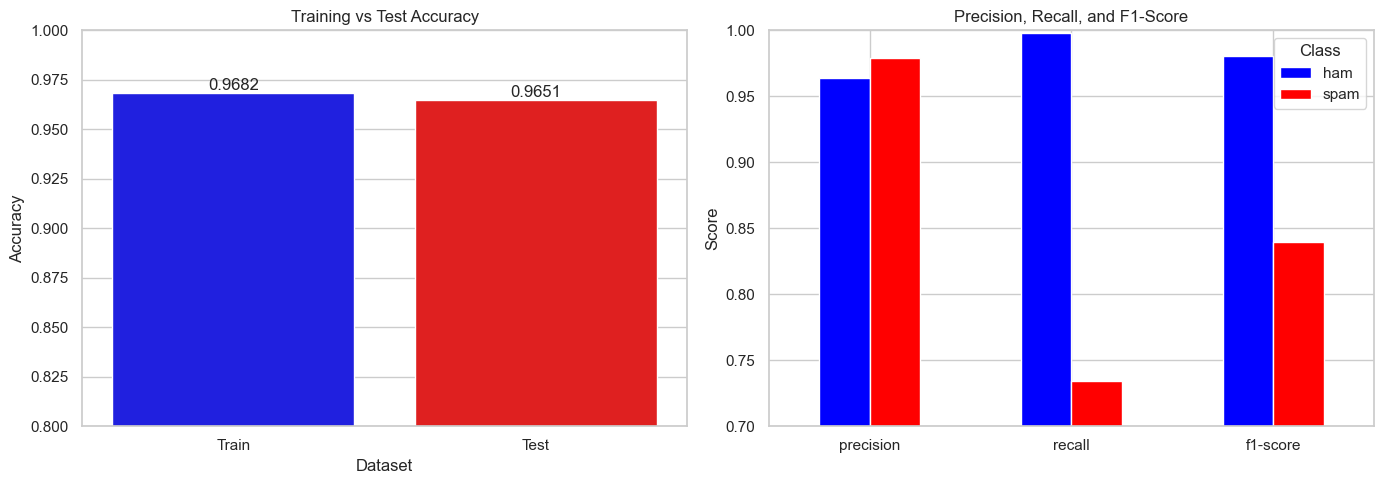

,precision,recall,f1-score,support
ham,0.963636,0.997785,0.980413,903.000000
spam,0.979167,0.734375,0.839286,128.000000
accuracy,0.965082,0.965082,0.965082,0.965082
macro avg,0.971402,0.866080,0.909850,1031.000000
weighted avg,0.965564,0.965082,0.962892,1031.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy],
})
sns.barplot(data=accuracy_df, x="Dataset", y="Accuracy", hue="Dataset", palette=["blue", "red"], ax=axes[0], legend=False)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f")

metrics_df = report_df.loc[["ham", "spam"], ["precision", "recall", "f1-score"]].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

report_df


In [6]:
import joblib

loaded_model = joblib.load(MODEL_PATH)
# test_text = "Congratulations! You have won a free prize. Reply now to claim it."
#test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"
test_text = "Dear Customer your pyatm wallet Has been booked and hold Your amount please complete your kyc contact customer care 7044518857"

prediction = loaded_model.predict([test_text])[0]
print(prediction)


ham
